In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

In [3]:
df=pd.read_csv("diabetes.csv")


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [7]:
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [11]:
df=df.drop(['ID','No_Pation'],axis=1) #we donot need this column for future analysis

In [13]:
df['Gender'].unique() #results shows F,M and f . So f is converted into F at next step

array(['F', 'M', 'f'], dtype=object)

In [15]:
df['Gender']=df['Gender'].replace('f', 'F')

In [21]:
df['CLASS'].unique() #got two Ys and two Ns as must be only one of them

array(['N', 'N ', 'P', 'Y', 'Y '], dtype=object)

In [23]:
df['CLASS']=df['CLASS'].replace({'Y ':'Y','N ':'N'})

In [27]:
df['CLASS'].unique() #still include P also as a value so removing is next step 

array(['N', 'P', 'Y'], dtype=object)

In [29]:
df=df.drop(df[df['CLASS']=='P'].index)

In [31]:
df['CLASS'].unique() #good to go

array(['N', 'Y'], dtype=object)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947 entries, 0 to 999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  947 non-null    object 
 1   AGE     947 non-null    int64  
 2   Urea    947 non-null    float64
 3   Cr      947 non-null    int64  
 4   HbA1c   947 non-null    float64
 5   Chol    947 non-null    float64
 6   TG      947 non-null    float64
 7   HDL     947 non-null    float64
 8   LDL     947 non-null    float64
 9   VLDL    947 non-null    float64
 10  BMI     947 non-null    float64
 11  CLASS   947 non-null    object 
dtypes: float64(8), int64(2), object(2)
memory usage: 96.2+ KB


In [37]:
#replacing N and Y in CLASS column to 0 and 1
df['CLASS']=df['CLASS'].replace({'N':0,'Y':1})

In [43]:
#replacing age gender into 0 and 1
df['Gender']=df['Gender'].replace({'F':0,'M':1})

# Analysis

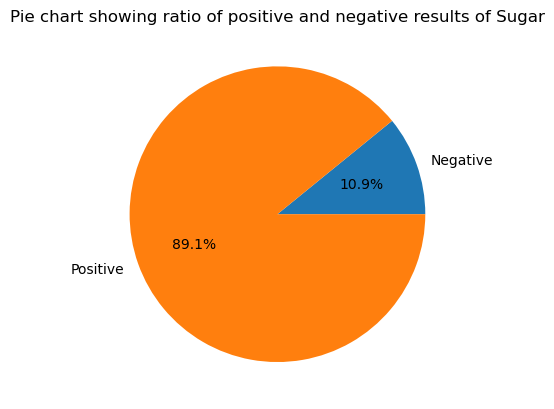

In [63]:
negative=(df['CLASS']==0).sum()
positive=(df['CLASS']==1).sum()
results=[negative,positive]
labels=['Negative', 'Positive']

plt.pie(results, labels=labels,autopct='%1.1f%%')
plt.title("Pie chart showing ratio of positive and negative results of Sugar")
plt.show()

In [74]:
# Standardize BMI and HbA1c
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['BMI_scaled', 'HbA1c_scaled','Chol_scaled']] = scaler.fit_transform(df[['BMI', 'HbA1c','Chol']])


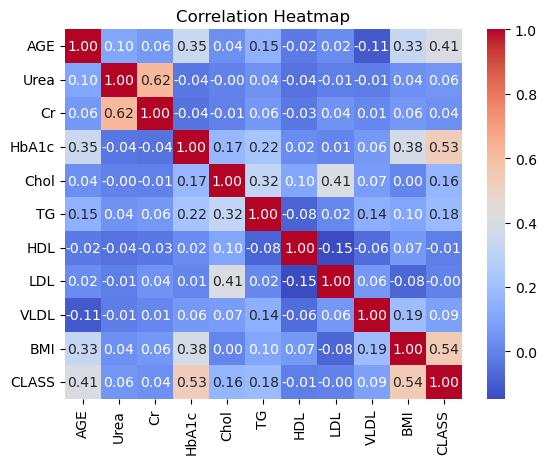

In [89]:
correlation_matrix=df[['AGE','Urea','Cr','HbA1c','Chol','TG','HDL','LDL','VLDL','BMI','CLASS']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

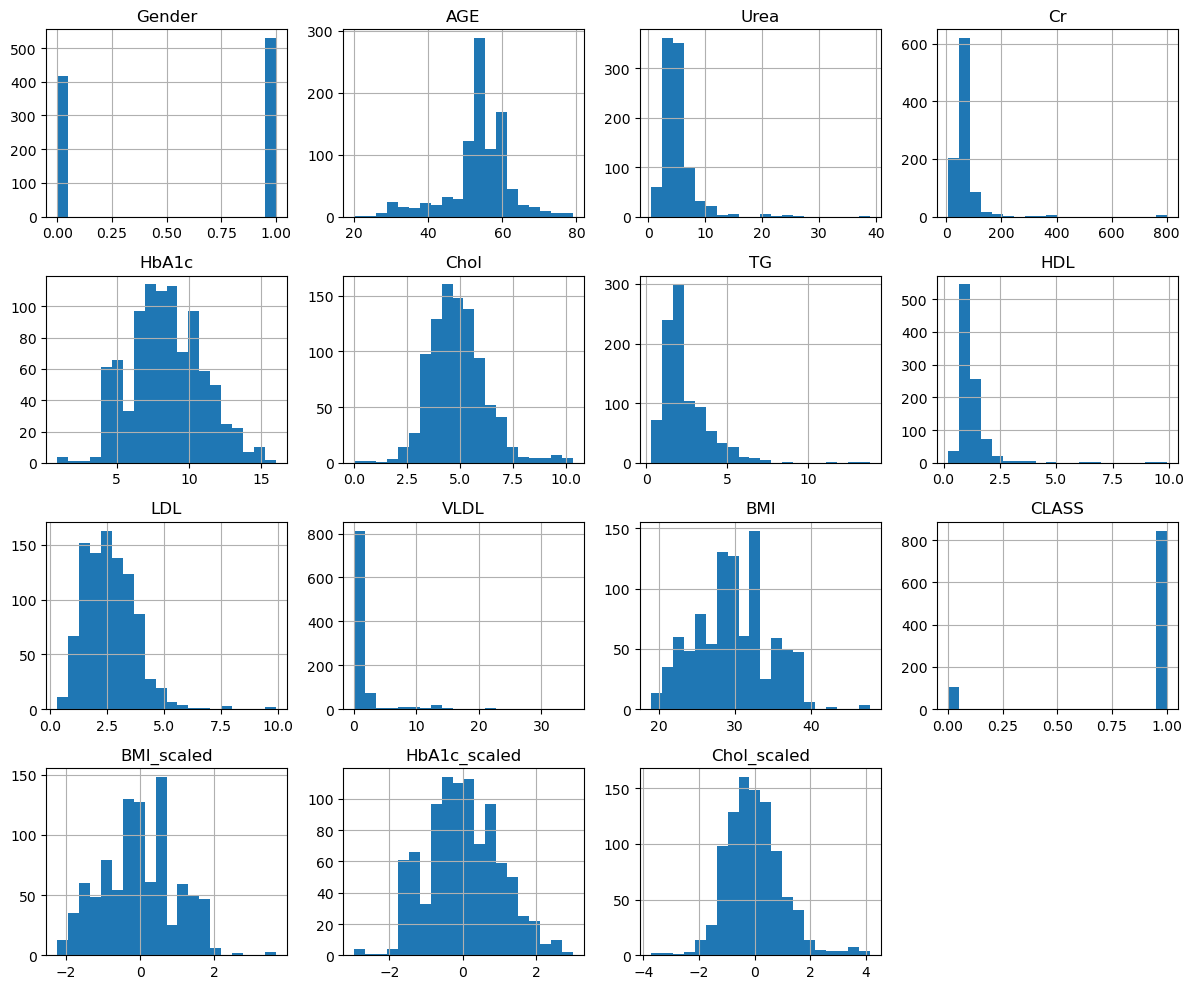

In [85]:
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

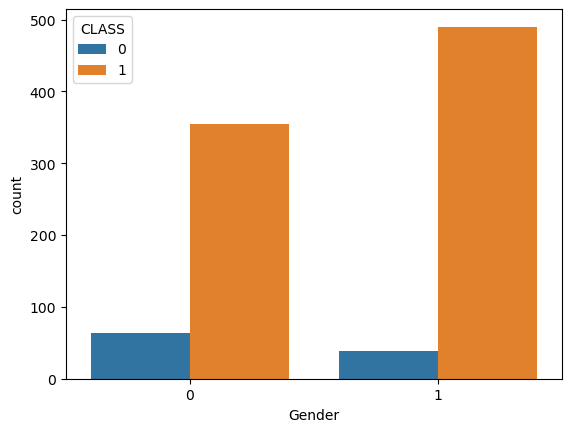

In [99]:



sns.countplot(x='Gender',data=df, hue='CLASS')
plt.show()

/Users/sagarbasnet/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sagarbasnet/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sagarbasnet/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sagarbasnet/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in 

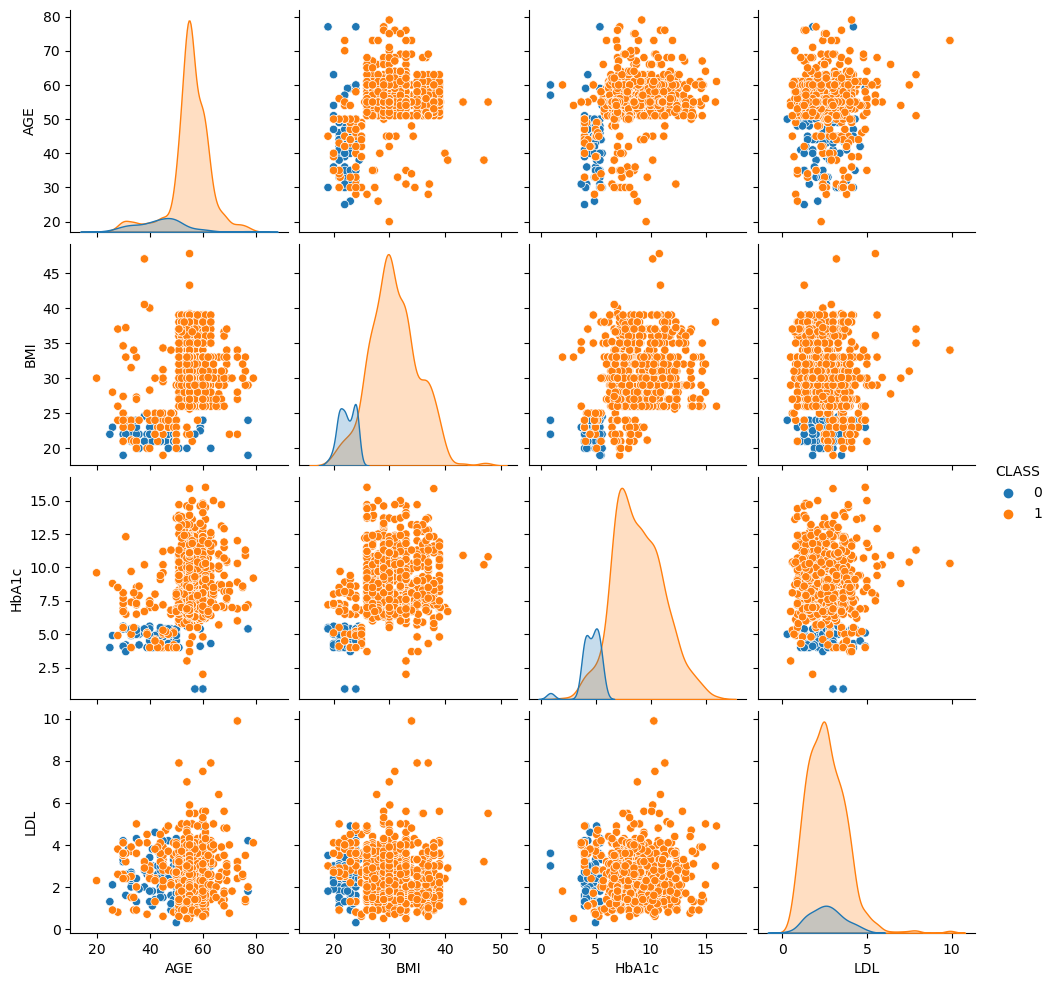

In [107]:


sns.pairplot(df, hue='CLASS', diag_kind='kde', vars=['AGE', 'BMI', 'HbA1c', 'LDL'])
plt.show()


Data Preprocessing

In [117]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
le_gender=LabelEncoder()
le_class=LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])
df['CLASS'] = le_class.fit_transform(df['CLASS'])

In [119]:
# seperating dataset into features X and target y
X=df.drop('CLASS',axis=1)
y=df['CLASS']

In [123]:
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

In [127]:
#splitting training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify =y)

In [133]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree

In [135]:
clf=tree.DecisionTreeClassifier()
clf=clf.fit(X_train,y_train)

[Text(0.625, 0.9285714285714286, 'x[4] <= -1.085\ngini = 0.193\nsamples = 757\nvalue = [82, 675]'),
 Text(0.5, 0.7857142857142857, 'x[13] <= 0.054\ngini = 0.433\nsamples = 120\nvalue = [82, 38]'),
 Text(0.25, 0.6428571428571429, 'x[10] <= -1.057\ngini = 0.184\nsamples = 78\nvalue = [70, 8]'),
 Text(0.125, 0.5, 'gini = 0.0\nsamples = 70\nvalue = [70, 0]'),
 Text(0.375, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.75, 0.6428571428571429, 'x[6] <= -0.326\ngini = 0.408\nsamples = 42\nvalue = [12, 30]'),
 Text(0.625, 0.5, 'x[10] <= -1.108\ngini = 0.496\nsamples = 22\nvalue = [12, 10]'),
 Text(0.5, 0.35714285714285715, 'x[7] <= 0.507\ngini = 0.415\nsamples = 17\nvalue = [12, 5]'),
 Text(0.375, 0.21428571428571427, 'x[2] <= 0.552\ngini = 0.245\nsamples = 14\nvalue = [12, 2]'),
 Text(0.25, 0.07142857142857142, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.5, 0.07142857142857142, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.625, 0.21428571428571427, 'gini = 0.0\nsampl

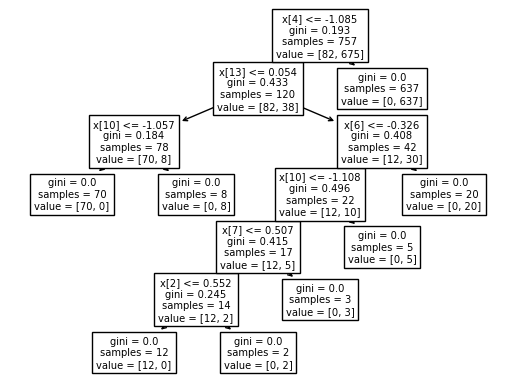

In [137]:
tree.plot_tree(clf)

In [139]:
prediction=clf.predict (X_test)

In [141]:
from sklearn.metrics import accuracy_score

In [145]:
accuracy=accuracy_score(y_test,prediction)

In [147]:
accuracy

0.9947368421052631

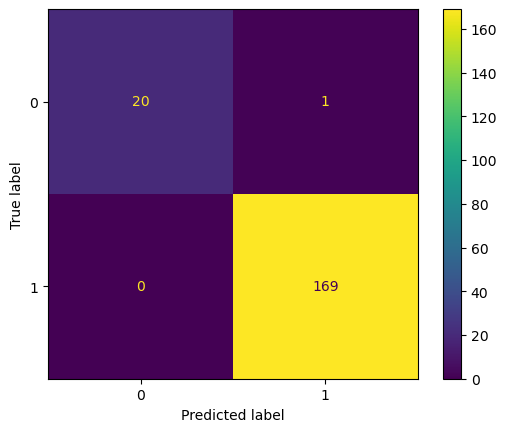

In [149]:
cm= confusion_matrix(y_test,prediction,labels=clf.classes_)
display= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
display.plot()
plt.show()

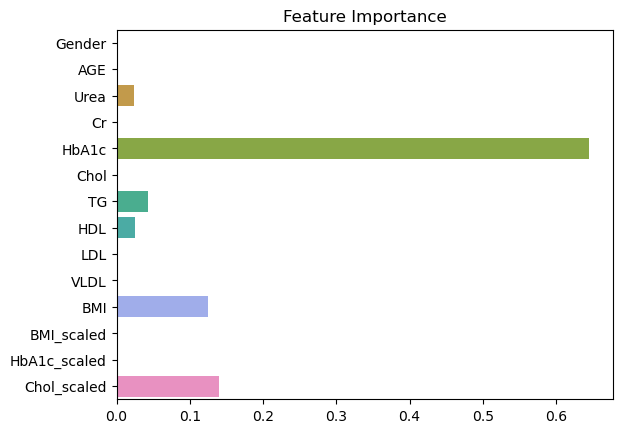

In [157]:
#ploting feature importance
importances= clf.feature_importances_
features=X.columns
sns.barplot(x=importances,y=features)
plt.title('Feature Importance')
plt.show()

In [159]:
#checking if there is any overfitting
train_accuracy=clf.score(X_train,y_train)
test_accuracy=clf.score(X_test,y_test)
print("Training Accuracy :", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy : 1.0
Testing Accuracy: 0.9947368421052631


ROC-AUC Score: 0.9761904761904762


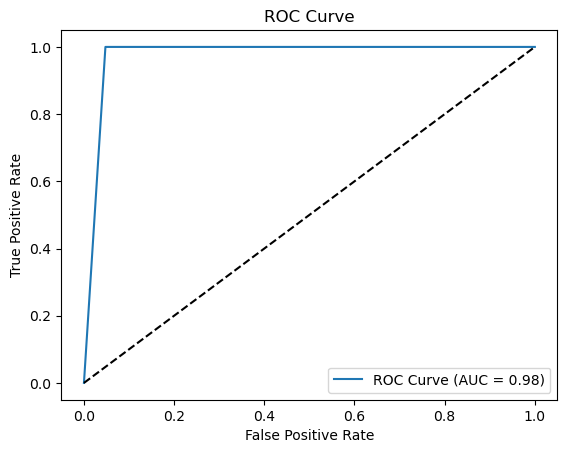

In [161]:
#evaluation using metrics
from sklearn.metrics import roc_auc_score, roc_curve
# ROC-AUC
y_proba = clf.predict_proba(X_test)[:, 1]  # For binary classification
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [163]:
#cross validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(clf, X_scaled, y, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))


Cross-Validation Scores: [0.83157895 0.98947368 1.         0.98412698 0.99470899]
Mean CV Score: 0.9599777220829852


In [ ]:
import pickle
with open('diabetes_model.pkl','wb') as file:
    pickle.dump(clf, file)